# Exploratory Data Analysis - CLINC150

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from data_loader import load_clinc

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

data = load_clinc(use_sample=False)
train_texts, train_labels = data['train_texts'], data['train_labels']
val_texts, val_labels = data['val_texts'], data['val_labels']
test_texts, test_labels = data['test_texts'], data['test_labels']
num_classes = data['num_classes']

all_texts = train_texts + val_texts + test_texts
all_labels = train_labels + val_labels + test_labels

print(f"Train: {len(train_texts)}, Val: {len(val_texts)}, Test: {len(test_texts)}")
print(f"Total: {len(all_texts)}, Classes: {num_classes}")

15250 / 3100 / 5500, 151 classes (full)
Train: 15250, Val: 3100, Test: 5500
Total: 23850, Classes: 151


## 1. Class Distribution

Min samples per class: 100
Max samples per class: 250
Mean: 101.0, Std: 12.2
Median: 100


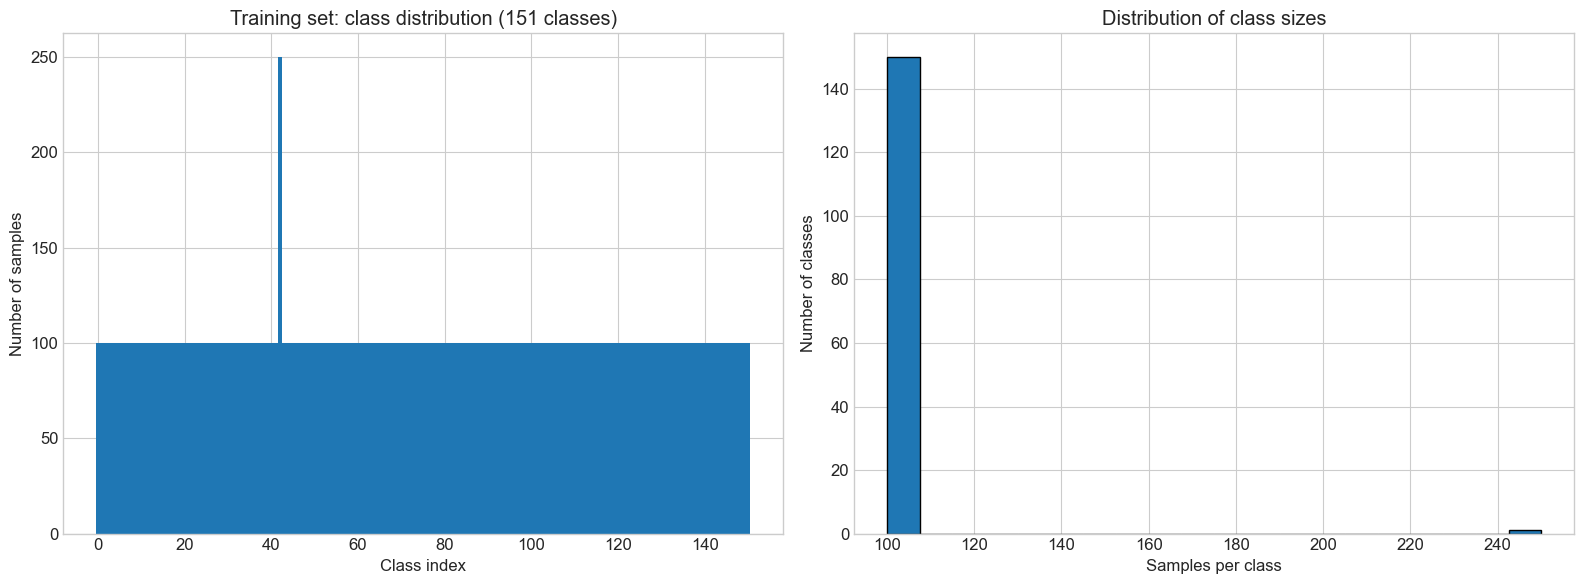


OOS class index: 42
OOS train samples: 250
OOS is larger than median class


In [2]:
label_names_map = {}
with open('data/train_sample.jsonl') as f:
    for line in f:
        obj = json.loads(line)
        label_names_map[obj['label']] = obj['label_text']
label_names = [label_names_map[i] for i in range(len(label_names_map))]

train_counter = Counter(train_labels)
classes = sorted(train_counter.keys())
counts = [train_counter[c] for c in classes]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(range(len(counts)), counts, width=1.0)
axes[0].set_xlabel('Class index')
axes[0].set_ylabel('Number of samples')
axes[0].set_title(f'Training set: class distribution ({num_classes} classes)')

print(f"Min samples per class: {min(counts)}")
print(f"Max samples per class: {max(counts)}")
print(f"Mean: {np.mean(counts):.1f}, Std: {np.std(counts):.1f}")
print(f"Median: {np.median(counts):.0f}")

axes[1].hist(counts, bins=20, edgecolor='black')
axes[1].set_xlabel('Samples per class')
axes[1].set_ylabel('Number of classes')
axes[1].set_title('Distribution of class sizes')

plt.tight_layout()
plt.savefig('results/eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

oos_idx = label_names.index('oos') if 'oos' in label_names else None
if oos_idx is not None:
    print(f"\nOOS class index: {oos_idx}")
    print(f"OOS train samples: {train_counter.get(oos_idx, 0)}")
    print(f"OOS is {'larger' if train_counter.get(oos_idx, 0) > np.median(counts) else 'smaller'} than median class")

## 2. Text Length Distribution

C:\Users\Milana Horalevych\AppData\Local\Temp\ipykernel_24560\2450431542.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(box_data, labels=box_labels, vert=True)


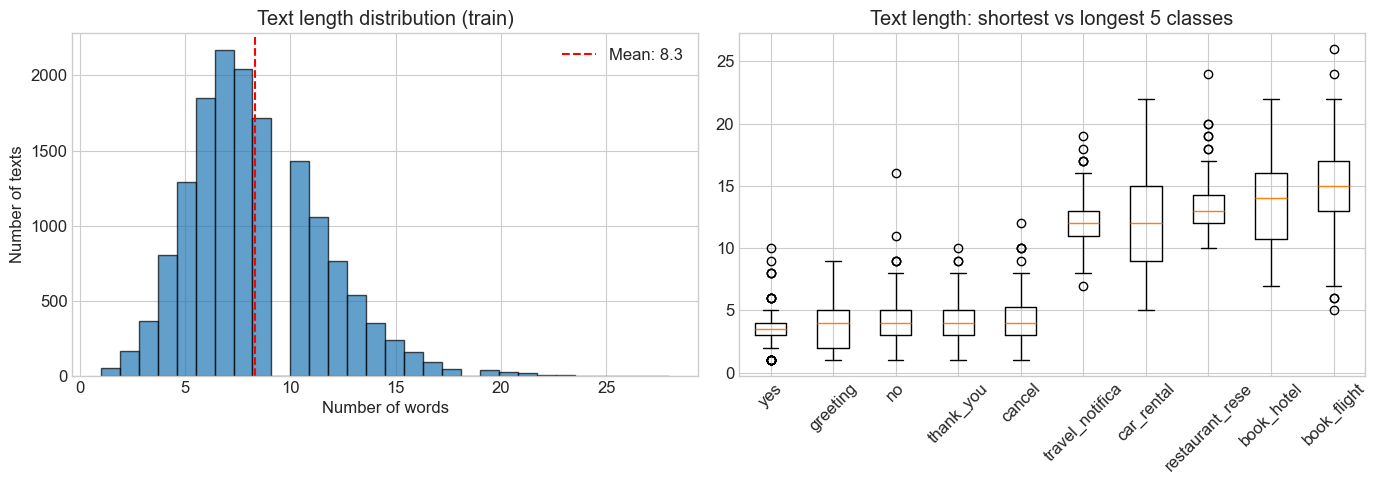

Min length: 1 words
Max length: 28 words
Mean: 8.3, Median: 8


In [3]:
train_lengths = [len(t.split()) for t in train_texts]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_lengths, bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of words')
axes[0].set_ylabel('Number of texts')
axes[0].set_title('Text length distribution (train)')
axes[0].axvline(np.mean(train_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(train_lengths):.1f}')
axes[0].legend()

# length by class (boxplot for top/bottom classes)
lengths_by_class = {}
for text, label in zip(train_texts, train_labels):
    lengths_by_class.setdefault(label, []).append(len(text.split()))

mean_lengths = {k: np.mean(v) for k, v in lengths_by_class.items()}
sorted_classes = sorted(mean_lengths.keys(), key=lambda x: mean_lengths[x])
top5 = sorted_classes[-5:]
bot5 = sorted_classes[:5]
selected = bot5 + top5

box_data = [lengths_by_class[c] for c in selected]
box_labels = [label_names[c][:15] for c in selected]
axes[1].boxplot(box_data, labels=box_labels, vert=True)
axes[1].set_title('Text length: shortest vs longest 5 classes')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('results/eda_text_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Min length: {min(train_lengths)} words")
print(f"Max length: {max(train_lengths)} words")
print(f"Mean: {np.mean(train_lengths):.1f}, Median: {np.median(train_lengths):.0f}")

## 3. Vocabulary and Lexical Overlap

In [4]:
class_vocabs = {}
for text, label in zip(train_texts, train_labels):
    words = set(text.lower().split())
    class_vocabs.setdefault(label, set()).update(words)

all_words = set()
for v in class_vocabs.values():
    all_words.update(v)
print(f"Total unique words: {len(all_words)}")

vocab_sizes = [len(v) for v in class_vocabs.values()]
print(f"Avg vocab per class: {np.mean(vocab_sizes):.0f} (std={np.std(vocab_sizes):.0f})")

class_ids = sorted(class_vocabs.keys())
overlaps = []
for i, c1 in enumerate(class_ids):
    for c2 in class_ids[i+1:]:
        jaccard = len(class_vocabs[c1] & class_vocabs[c2]) / len(class_vocabs[c1] | class_vocabs[c2])
        overlaps.append((c1, c2, jaccard))

overlaps.sort(key=lambda x: x[2], reverse=True)

print("\nTop 10 most lexically similar class pairs:")
for c1, c2, jac in overlaps[:10]:
    print(f"  {label_names[c1]:25s} - {label_names[c2]:25s}  Jaccard={jac:.3f}")

Total unique words: 6159
Avg vocab per class: 146 (std=60)

Top 10 most lexically similar class pairs:
  user_name                 - what_is_your_name          Jaccard=0.398
  pto_request_status        - application_status         Jaccard=0.386
  payday                    - next_holiday               Jaccard=0.366
  credit_score              - current_location           Jaccard=0.349
  credit_limit              - credit_limit_change        Jaccard=0.346
  change_language           - change_accent              Jaccard=0.342
  pto_balance               - pto_used                   Jaccard=0.342
  income                    - taxes                      Jaccard=0.333
  tire_change               - oil_change_when            Jaccard=0.330
  bill_due                  - min_payment                Jaccard=0.328


## 4. Example Texts

In [5]:
np.random.seed(42)
sample_classes = np.random.choice(class_ids, 5, replace=False)

for cls in sample_classes:
    cls_texts = [t for t, l in zip(train_texts, train_labels) if l == cls]
    print(f"\n{label_names[cls]} (index={cls}, {len(cls_texts)} samples)")
    for t in cls_texts[:3]:
        print(f"  - {t}")


reminder (index=76, 100 samples)
  - tell me my reminders
  - tell me my current reminders list
  - please read my reminders

schedule_meeting (index=18, 100 samples)
  - i want to know if there is meeting room available at 8
  - meeting room availability from 8:00 please
  - are there any meetings room available between 8:00 and 9:00 am

greeting (index=82, 100 samples)
  - how's everything
  - how are things going
  - hello, anyone there

find_phone (index=81, 100 samples)
  - i need help finding my mobile phone
  - help me figure out where my cell phone is
  - give me a hand finding my mobile device

min_payment (index=143, 100 samples)
  - what's the minimum i owe on the car payment
  - what's the least amount i need to pay on the electric bill
  - what's the smallest amount i can pay on the water bill


## 5. Summary Statistics

In [6]:
summary = {
    "dataset": "CLINC150 (plus configuration)",
    "total_samples": len(all_texts),
    "train_samples": len(train_texts),
    "val_samples": len(val_texts),
    "test_samples": len(test_texts),
    "num_classes": num_classes,
    "includes_oos": True,
    "min_samples_per_class": min(counts),
    "max_samples_per_class": max(counts),
    "mean_text_length_words": round(np.mean(train_lengths), 1),
    "median_text_length_words": int(np.median(train_lengths)),
    "total_unique_words": len(all_words),
    "label_names": label_names,
    "class_imbalance_ratio": max(counts) / min(counts),
    "top10_lexical_overlaps": [
        {"class1_name": label_names[c1], "class2_name": label_names[c2], "jaccard": round(jac, 4)}
        for c1, c2, jac in overlaps[:10]
    ],
}

for k, v in summary.items():
    print(f"{k:30s}: {v}")

with open('results/eda_summary.json', 'w') as f:
    json.dump(summary, f, indent=4)

print("\nSaved: results/eda_summary.json")

dataset                       : CLINC150 (plus configuration)
total_samples                 : 23850
train_samples                 : 15250
val_samples                   : 3100
test_samples                  : 5500
num_classes                   : 151
includes_oos                  : True
min_samples_per_class         : 100
max_samples_per_class         : 250
mean_text_length_words        : 8.3
median_text_length_words      : 8
total_unique_words            : 6159
label_names                   : ['restaurant_reviews', 'nutrition_info', 'account_blocked', 'oil_change_how', 'time', 'weather', 'redeem_rewards', 'interest_rate', 'gas_type', 'accept_reservations', 'smart_home', 'user_name', 'report_lost_card', 'repeat', 'whisper_mode', 'what_are_your_hobbies', 'order', 'jump_start', 'schedule_meeting', 'meeting_schedule', 'freeze_account', 'what_song', 'meaning_of_life', 'restaurant_reservation', 'traffic', 'make_call', 'text', 'bill_balance', 'improve_credit_score', 'change_language', 'no', 'me